In [ ]:
#libraries
import pandas as pd
import matplotlib.pyplot as plt     
import matplotlib.dates as mdates   
import seaborn as sns
import numpy as np  

# Load the dataset 
df=pd.read_csv(r"C:\Users\300\Downloads\Walmart.csv")   

In [ ]:
# Display the first few rows of the dataframe
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# Get a summary of the dataframe
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)

In [30]:
#sort by time
df = df.sort_values(by = 'Date')

Text(0, 0.5, 'Weekly Sales')

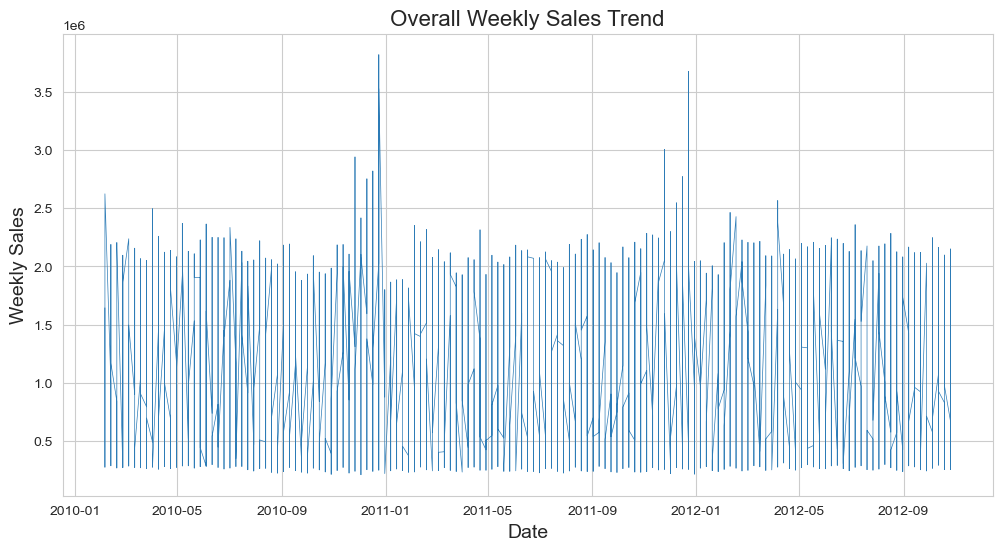

In [31]:
#Overall demand trend 
# Set a clean, professional style
sns.set_style("whitegrid")  
plt.figure(figsize=(12, 6))
# Plot the data with a slightly thinner line and better color
plt.plot(df['Date'], df['Weekly_Sales'], color='#2c7bb6', linewidth=0.5)
plt.title('Overall Weekly Sales Trend', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Weekly Sales', fontsize=14) 


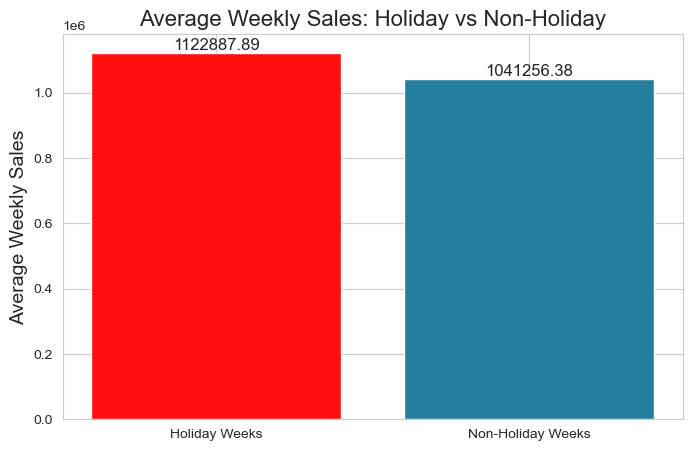

In [ ]:
# Demand during holiday vs non-holiday weeks
holiday_demand = df[df['Holiday_Flag'] == 1].mean()['Weekly_Sales']
non_holiday_demand = df[df['Holiday_Flag'] == 0].mean()['Weekly_Sales']

plt.figure(figsize=(8, 5))
bars = plt.bar(['Holiday Weeks', 'Non-Holiday Weeks'], [holiday_demand, non_holiday_demand], color=["#ff0e0e", "#237f9d"])
plt.title('Average Weekly Sales: Holiday vs Non-Holiday', fontsize=16)
plt.ylabel('Average Weekly Sales', fontsize=14)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+ bar.get_width()/2 , yval + 500, round(yval, 2), ha='center', va='bottom', fontsize=12)


In [ ]:
# Top 10 stores by average weekly sales
df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10).round(2)


Store
20    2107676.87
4     2094712.96
14    2020978.40
13    2003620.31
2     1925751.34
10    1899424.57
27    1775216.20
6     1564728.19
1     1555264.40
39    1450668.13
Name: Weekly_Sales, dtype: float64

In [ ]:
# Time series of total weekly sales across all stores
ts = df.groupby(['Date'])['Weekly_Sales'].sum().reset_index()
ts = ts.sort_values('Date')
ts.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [ ]:
# Set 'Date' as the index
ts.set_index('Date', inplace=True)


In [ ]:
# Calculate moving averages
ts["MA-4"] = ts['Weekly_Sales'].rolling(window=4).mean()
ts["MA-12"] = ts['Weekly_Sales'].rolling(window=12).mean()

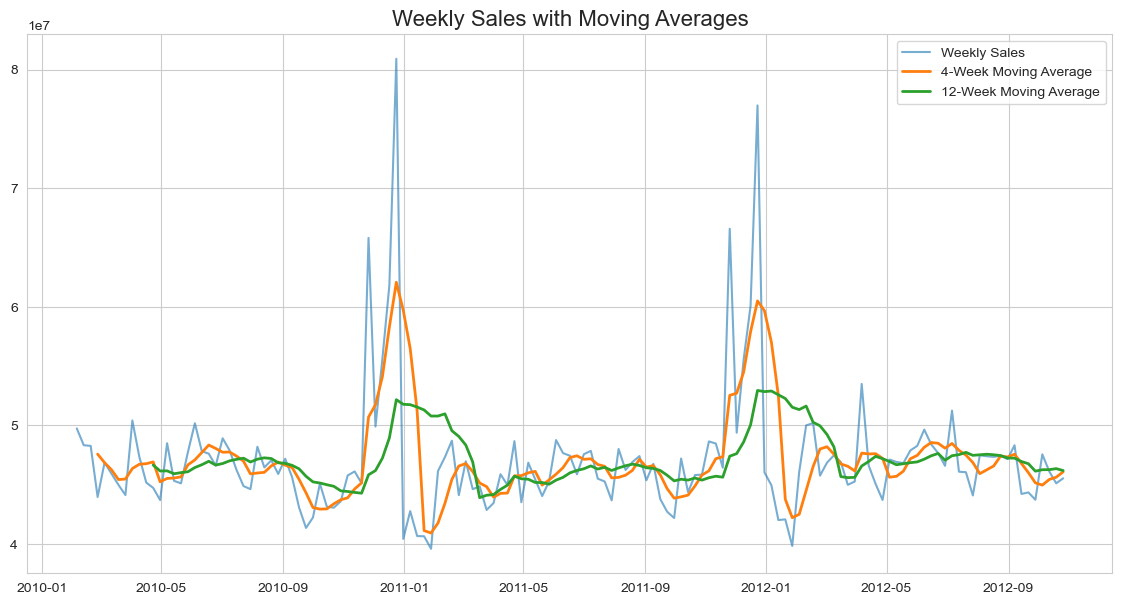

In [ ]:
# Plot the time series with moving averages
plt.figure(figsize=(14, 7))
plt.plot(ts.index, ts['Weekly_Sales'], label='Weekly Sales', color='#1f77b4', alpha=0.6)
plt.plot(ts.index, ts['MA-4'], label='4-Week Moving Average', color='#ff7f0e', linewidth=2)
plt.plot(ts.index, ts['MA-12'], label='12-Week Moving Average', color='#2ca02c', linewidth=2)
plt.title('Weekly Sales with Moving Averages', fontsize=16) 
plt.legend()

In [ ]:
# Holt-Winters Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing 
model_hw = ExponentialSmoothing(ts['Weekly_Sales'], seasonal='add',trend='add', seasonal_periods=52)
hw_fit = model_hw.fit()
ts['HW_Forecast'] = hw_fit.fittedvalues



c:\Users\300\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\300\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [ ]:
# Forecast the next 12 weeks
# 1. Generate the forecasted values
forecast_12 = hw_fit.forecast(12)

# 2. Create a temporary DataFrame for the future values
future_df = pd.DataFrame(index=forecast_12.index)
future_df['HW_Forecast'] = forecast_12

# 3. Use concat to add these rows to your original dataframe
ts = pd.concat([ts, future_df])

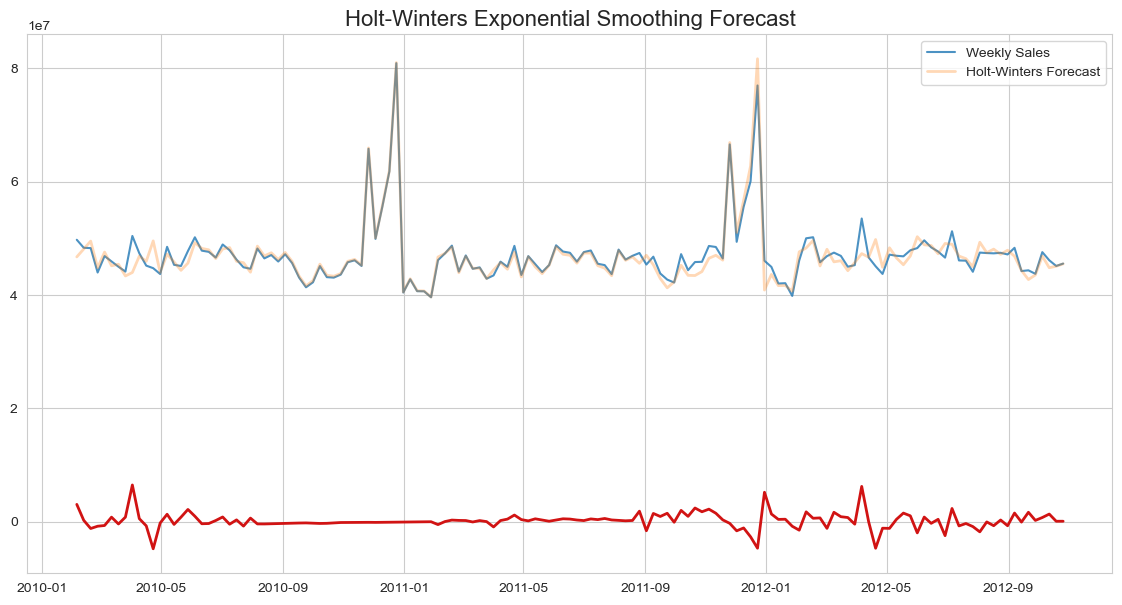

In [ ]:
# Plot the time series with Holt-Winters forecast
plt.figure(figsize=(14, 7))
plt.plot(ts.index, ts['Weekly_Sales'], label='Weekly Sales', color='#1f77b4', alpha=0.8)
plt.plot(ts.index, ts['HW_Forecast'], label='Holt-Winters Forecast', color='#ff7f0e', linewidth=2, alpha=0.3)
plt.legend()
plt.title('Holt-Winters Exponential Smoothing Forecast', fontsize=16)
plt.plot(ts.index, ts['Weekly_Sales']-ts['HW_Forecast'], label='diff', color="#d11313", linewidth=2)

In [ ]:
# ADF Test for stationarity
from statsmodels.tsa.stattools import adfuller

def test_stationarity(ts):
    result = adfuller(ts)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Series is stationary (d=0)")
    else:
        print("Series is non-stationary (need differencing)")

# Test original series
test_stationarity(ts['Weekly_Sales'])

# If p-value > 0.05, difference once
ts_diff = ts['Weekly_Sales'].diff().dropna()
test_stationarity(ts_diff)


ADF Statistic: -5.908297957186332
p-value: 2.675979158986058e-07
Series is stationary (d=0)
ADF Statistic: -6.69946930961721
p-value: 3.922578707076961e-09
Series is stationary (d=0)


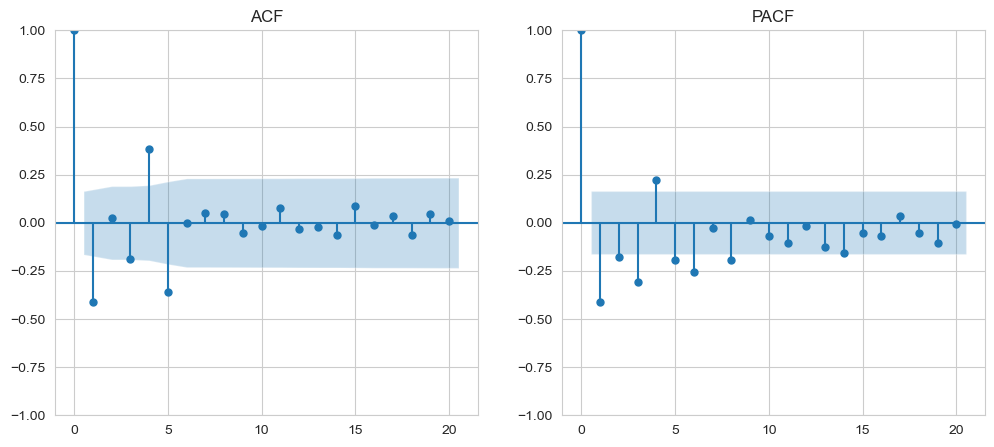

In [ ]:
# ACF and PACF plots
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts_to_use = ts_diff if 'ts_diff' in locals() else ts['Weekly_Sales']

plt.figure(figsize=(12,5))
plt.subplot(121)
plot_acf(ts_to_use, lags=20, ax=plt.gca(), title='ACF')
plt.subplot(122)
plot_pacf(ts_to_use, lags=20, ax=plt.gca(), title='PACF')
plt.show()


In [ ]:
#from the plots, we can choose p=1, d=1, q=1
# ARIMA Modeling
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(ts['Weekly_Sales'], order=(1,1,1)).fit()
ts['ARIMA_Forecast'] = arima_model.fittedvalues


c:\Users\300\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\300\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\300\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


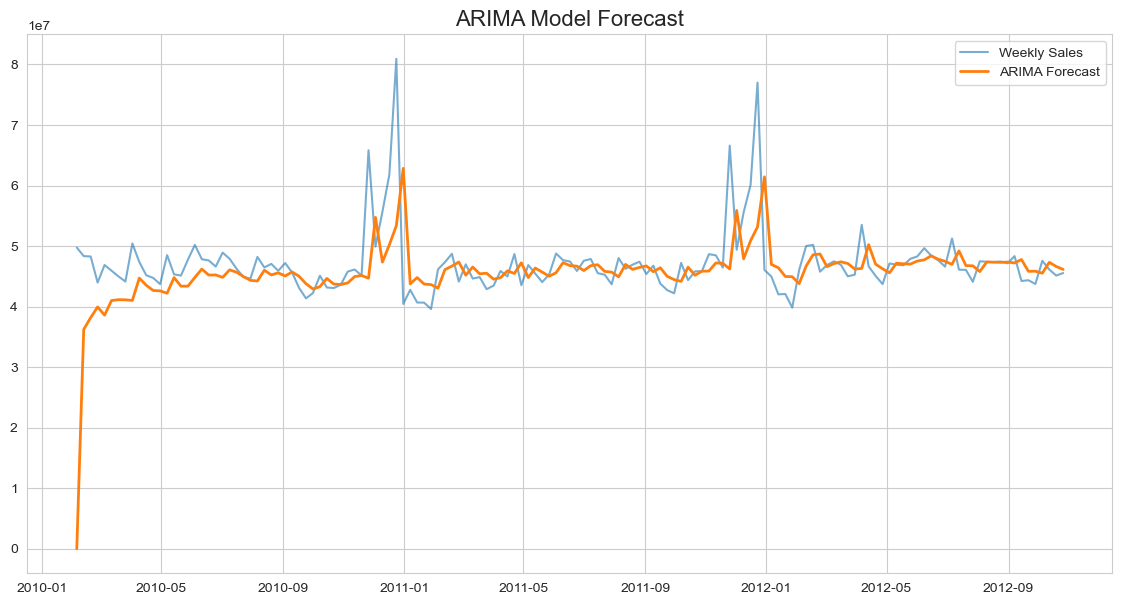

In [ ]:
# Plot the time series with ARIMA forecast
plt.figure(figsize=(14, 7))
plt.plot(ts.index, ts['Weekly_Sales'], label='Weekly Sales', color='#1f77b4', alpha=0.6)
plt.plot(ts.index, ts['ARIMA_Forecast'], label='ARIMA Forecast', color='#ff7f0e', linewidth=2)
plt.title('ARIMA Model Forecast', fontsize=16)
plt.legend()

In [ ]:
# Evaluation Metrics
def mape(actual, forecast):
    actual, forecast = np.array(actual), np.array(forecast)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100



In [ ]:

# Calculate MAPE for Holt-Winters
mape_hw = mape(ts['Weekly_Sales'], ts['HW_Forecast'])
mape_hw


np.float64(1.8484529144501272)

In [ ]:
# Calculate MAPE for ARIMA
mape_arima = mape(ts['Weekly_Sales'][-12:], ts['ARIMA_Forecast'][-12:])
mape_arima


np.float64(2.5679381511153667)

In [ ]:
# Calculate MAPE for MA-4
mape_ma4 = mape(ts['Weekly_Sales'][-12:], ts['MA-4'][-12:])
mape_ma4

np.float64(2.3438754969687166)

In [ ]:
# Calculate MAPE for MA-12
mape_ma12 = mape(ts['Weekly_Sales'][-12:], ts['MA-12'][-12:])
mape_ma12

np.float64(2.2974510682420646)

In [ ]:
# Summary of results
results = pd.DataFrame({
    "Model": ["Moving Average (4)", "Moving Average (12)", "Holt-Winters", "ARIMA"],
    "MAPE (%)": [mape_ma4,mape_ma12, mape_hw, mape_arima]
})

results


,Model,MAPE (%)
0,Moving Average (4),2.343875
1,Moving Average (12),2.297451
2,Holt-Winters,1.848453
3,ARIMA,2.567938


In [ ]:
# Export forecast results for dashboard
dashboard_df = pd.DataFrame({
    "Date": ts.index,
    "Actual": ts['Weekly_Sales'].values,
    "Forecast": ts['HW_Forecast'].values
})

dashboard_df.to_csv("forecast_output.csv", index=False)



In [ ]:
# Export model performance metrics
results.to_csv("model_performance.csv", index=False)